# H1N1 subclade 比例预测：数据读取与时间分布图

本 notebook 只在本地使用 Pandas 读取 Nextclade TSV；不会把逐行数据发送给大模型，也不会修改原始文件。当前步骤读取必要字段、检查 `columns/head`，按 collection date 做 14-day bin，并从 2017 年开始绘制 Nextclade subclade 比例堆积图。默认遵循新版比赛口径，也可通过 `LABEL_MODE = 'legacy'` 切回旧体系。

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'src' else Path.cwd().resolve()
SRC_DIR = PROJECT_ROOT / 'src'
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.h1n1_subclade_plot import (
    DEFAULT_START_DATE,
    build_binned_tables,
    plot_subclade_area,
    read_nextclade_table,
)

INPUT_TSV = PROJECT_ROOT / 'clade注释_sorted/H1N1/h1n1_results_MW626062_sorted.tsv'
LABEL_MODE = 'nextclade'  # nextclade / legacy
OUTPUT_PNG = PROJECT_ROOT / f'outputs/h1n1_demo/h1n1_{LABEL_MODE}_subclade_proportions_from_2017.png'
START_DATE = DEFAULT_START_DATE
END_DATE = None
BIN_DAYS = 14

assert INPUT_TSV.exists(), f'Input file not found: {INPUT_TSV}'
INPUT_TSV

PosixPath('/Users/oliver/Desktop/Alright-strain/clade注释_sorted/H1N1/h1n1_results_MW626062_sorted.tsv')

## 1. 读取必要字段并做小规模检查

读取函数只载入 `seqName`、`legacy-clade`、`subclade` 和 `clade`。collection date 从 `seqName` 中第一个完整 ISO 日期提取。默认 `LABEL_MODE = 'nextclade'`，此时 `prediction_branch` 按 `subclade -> clade -> legacy-clade` 回退；设置为 `'legacy'` 时按 `legacy-clade -> subclade -> clade` 回退。所有字段都无有效值时记为 `Unassigned`。

In [2]:
records = read_nextclade_table(INPUT_TSV, label_mode=LABEL_MODE)
print(f'Label mode: {LABEL_MODE}')
print(f'Rows loaded: {len(records):,}')
print('Columns:', records.columns.tolist())
display(records[['collection_date', 'legacy-clade', 'subclade', 'clade', 'prediction_branch']].head())

Label mode: nextclade
Rows loaded: 165,911
Columns: ['seqName', 'clade', 'subclade', 'legacy-clade', 'collection_date', 'prediction_branch']


,collection_date,legacy-clade,subclade,clade,prediction_branch
0,2012-12-04,<NA>,<NA>,<NA>,Unassigned
1,2012-12-04,<NA>,<NA>,<NA>,Unassigned
2,2023-12-11,6B.1A.5a.2a,C.1,C.1,C.1
3,2023-12-07,6B.1A.5a.2a,C.1.9,C.1.9,C.1.9
4,2023-12-12,6B.1A.5a.2a.1,D.2,D.2,D.2


In [3]:
summary = pd.Series({
    'rows': len(records),
    'valid_collection_dates': int(records['collection_date'].notna().sum()),
    'collection_date_min': records['collection_date'].min(),
    'collection_date_max': records['collection_date'].max(),
    'branches_including_unassigned': int(records['prediction_branch'].nunique()),
    'unassigned_rows': int(records['prediction_branch'].eq('Unassigned').sum()),
})
display(summary.to_frame('value'))

,value
rows,165911
valid_collection_dates,165911
collection_date_min,2009-01-01 00:00:00
collection_date_max,2026-09-20 00:00:00
branches_including_unassigned,41
unassigned_rows,126


## 2. 14-day counts 与 proportions

`counts` 保留所有14天 bin，包括没有记录的空 bin；`proportions` 在非空 bin 内按该 bin 总毒株数归一化。

In [4]:
counts, proportions, bin_totals = build_binned_tables(
    records,
    bin_days=BIN_DAYS,
    start_date=START_DATE,
    end_date=END_DATE,
)
print(f'Bins: {len(counts):,}; branches: {counts.shape[1]:,}; records in plotted period: {int(bin_totals.sum()):,}')
display(counts.head())
display(proportions.head())

Bins: 254; branches: 40; records in plotted period: 157,685


prediction_branch,Unassigned,6B.1,6B.1A,6B.1A.1,6B.1A.5b,6B,6B.1A.3,6B.1A.2,6B.1A.4,6B.1A.6,...,C.1.7,C.1.6,C.1.7.1,C.1.7.2,C.1.9.2,D.3,D.4,C.1.9.1,C.1.9.4,D.3.1.1
bin_start,,,,,,,,,,,,,,,,,,,,,
2017-01-01,1,137,7,3,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2017-01-15,0,140,2,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2017-01-29,0,124,2,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2017-02-12,0,97,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2017-02-26,0,96,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


prediction_branch,Unassigned,6B.1,6B.1A,6B.1A.1,6B.1A.5b,6B,6B.1A.3,6B.1A.2,6B.1A.4,6B.1A.6,...,C.1.7,C.1.6,C.1.7.1,C.1.7.2,C.1.9.2,D.3,D.4,C.1.9.1,C.1.9.4,D.3.1.1
bin_start,,,,,,,,,,,,,,,,,,,,,
2017-01-01,0.006757,0.925676,0.047297,0.020270,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-01-15,0.000000,0.979021,0.013986,0.000000,0.006993,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-01-29,0.000000,0.968750,0.015625,0.015625,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-02-12,0.000000,0.979798,0.010101,0.010101,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-02-26,0.000000,0.989691,0.010309,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3. 从 2017 年开始绘制并保存 Nextclade subclade 比例堆积图

画图时跳过没有任何记录的空 bin，使相邻观测点连续显示；这只影响展示，不改变 `counts` 和 `proportions` 表。

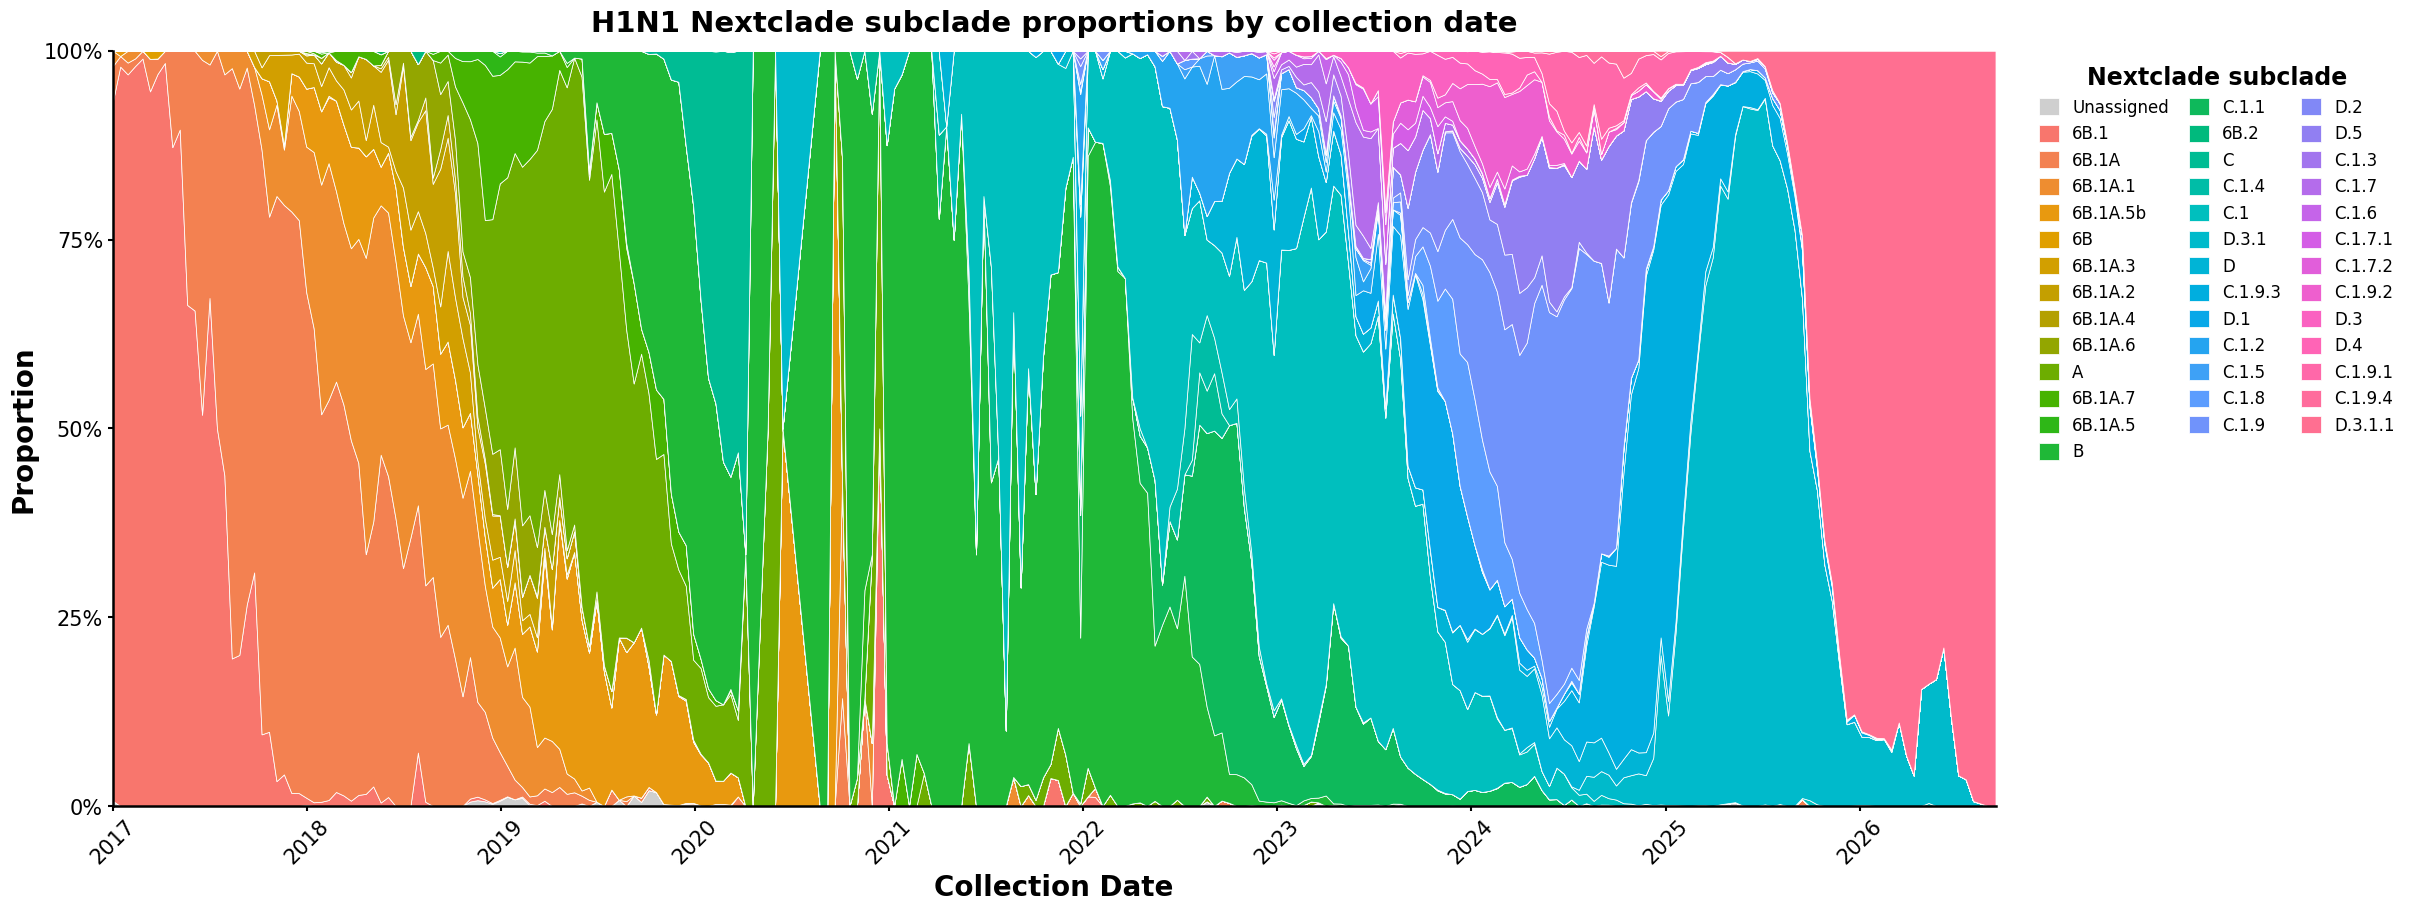

Saved to: /Users/oliver/Desktop/Alright-strain/outputs/h1n1_demo/h1n1_nextclade_subclade_proportions_from_2017.png


In [5]:
is_legacy = LABEL_MODE == 'legacy'
figure, axis = plot_subclade_area(
    proportions,
    output_path=OUTPUT_PNG,
    title=('H1N1 legacy subclade proportions by collection date' if is_legacy
           else 'H1N1 Nextclade subclade proportions by collection date'),
    legend_title='Legacy subclade' if is_legacy else 'Nextclade subclade',
)
display(figure)
plt.close(figure)
print(f'Saved to: {OUTPUT_PNG}')

## 4. 交互式调整起始年份和 bin 大小

In [ ]:
from ipywidgets import IntSlider, SelectionSlider, interact

def interactive_subclade_plot(start_year=2017, bin_days=14):
    _, interactive_proportions, interactive_totals = build_binned_tables(
        records,
        bin_days=bin_days,
        start_date=f'{start_year}-01-01',
    )
    fig, _ = plot_subclade_area(
        interactive_proportions,
        title=f'H1N1 Nextclade subclade proportions ({bin_days}-day bins)',
    )
    display(fig)
    plt.close(fig)
    print(f'Records shown: {int(interactive_totals.sum()):,}')

interact(
    interactive_subclade_plot,
    start_year=IntSlider(value=2017, min=2017, max=2025, step=1, description='Start year'),
    bin_days=SelectionSlider(options=[7, 14, 28], value=14, description='Bin days'),
);

## 5. B 系列 benchmark：统一时间回测

下面使用同一个历史截断点和未来 12 个 14-day bins，对三个 B 系列方法做可复现回测：

- **B0 persistence**：未来频率保持为截断点的最后观测值。
- **B1 frequency-trend regression**：对每个 subclade 的近期频率拟合加权线性趋势，再裁剪并归一化。
- **B2 renewal-selection**：从 centered log-frequency 的近期变化估计相对增长率，并按更新/选择方程递推未来比例。

In [ ]:
from src.h1n1_benchmarks import MODEL_LABELS, run_benchmark_backtest

BACKTEST_CUTOFF = pd.Timestamp('2024-12-31')
FORECAST_HORIZON_BINS = 12  # 12 * 14 = 168 days
BENCHMARK_LOOKBACK_BINS = 26  # about one year
BENCHMARK_OUTPUT_DIR = PROJECT_ROOT / 'outputs/h1n1_demo/benchmarks'
BENCHMARK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

benchmark_predictions, benchmark_actual, benchmark_metrics = run_benchmark_backtest(
    proportions,
    cutoff=BACKTEST_CUTOFF,
    horizon_bins=FORECAST_HORIZON_BINS,
    lookback_bins=BENCHMARK_LOOKBACK_BINS,
)
effective_cutoff = proportions.index[proportions.index <= BACKTEST_CUTOFF][-1]
print(f'Effective cutoff: {effective_cutoff.date()}')
print(f'Holdout: {benchmark_actual.index.min().date()} .. {benchmark_actual.index.max().date()}')
display(benchmark_metrics)

### 5.1 指标

所有指标均为越小越好：`MAE` / `RMSE` 是 branch-level 频率误差；`mean_TVD` 是每个时间点预测分布与真实分布的平均 total variation distance；`mean_JSD` 是平均 Jensen–Shannon divergence。

In [ ]:
metrics_path = BENCHMARK_OUTPUT_DIR / 'b_series_metrics.csv'
actual_path = BENCHMARK_OUTPUT_DIR / 'actual_holdout.csv'
benchmark_metrics.to_csv(metrics_path)
benchmark_actual.to_csv(actual_path)
for model_name, prediction in benchmark_predictions.items():
    prediction.to_csv(BENCHMARK_OUTPUT_DIR / f'{model_name.lower()}_predictions.csv')

print(f'Metrics saved to: {metrics_path}')
print(f'Predictions saved under: {BENCHMARK_OUTPUT_DIR}')

### 5.2 真实值与预测曲线

为避免图例过密，只展示 holdout 期平均占比最高的 6 个 subclades；评分仍使用全部 subclades。

In [ ]:
top_branches = benchmark_actual.mean().nlargest(6).index.tolist()
history_for_plot = proportions.loc[:effective_cutoff].tail(8)
model_colors = {'B0': '#7f7f7f', 'B1': '#1f77b4', 'B2': '#d62728'}
figure, axes = plt.subplots(2, 3, figsize=(18, 9), sharex=True, sharey=False, constrained_layout=True)

for axis, branch in zip(axes.flat, top_branches):
    axis.plot(history_for_plot.index, history_for_plot[branch], color='black', alpha=0.35, marker='o', label='History')
    axis.plot(benchmark_actual.index, benchmark_actual[branch], color='black', linewidth=2.5, marker='o', label='Actual')
    for model_name, prediction in benchmark_predictions.items():
        axis.plot(
            prediction.index, prediction[branch],
            color=model_colors[model_name], linewidth=1.8,
            label=MODEL_LABELS[model_name],
        )
    axis.axvline(effective_cutoff, color='black', linestyle=':', alpha=0.6)
    axis.set_title(branch, fontweight='bold')
    axis.set_ylim(bottom=0)
    axis.grid(alpha=0.2)
    axis.tick_params(axis='x', rotation=45)

handles, labels = axes.flat[0].get_legend_handles_labels()
figure.legend(handles, labels, loc='outside upper center', ncol=5, frameon=False)
figure.suptitle('H1N1 B-series benchmark: observed vs forecast Nextclade subclade proportions', fontweight='bold')
figure.supxlabel('Collection date')
figure.supylabel('Proportion')
benchmark_figure_path = BENCHMARK_OUTPUT_DIR / 'b_series_backtest.png'
figure.savefig(benchmark_figure_path, dpi=180, bbox_inches='tight', facecolor='white')
display(figure)
plt.close(figure)
print(f'Saved to: {benchmark_figure_path}')

### 5.3 与官方实现的边界

当前 notebook 中的 **B1/B2 是可直接运行的 frequency-only local proxies**，用于先建立统一的数据切分、预测输出和评分流程。它们不能冒充官方复现：

- 正式的 **Nextstrain forecasts-flu MLR** 还需要 timed tree 和 fitness predictors，并应通过官方容器运行。
- 正式的 **RelRe** 应把同一 cutoff 前的 counts 导出给 Julia 程序运行，再把结果映射回这里的 subclade 列和未来 bins。

后续接入官方输出时，只需生成与 `benchmark_actual` 同索引、同列定义的 DataFrame，即可复用 `evaluate_frequency_forecast` 和本节的绘图/导出逻辑。